# Variable-Cell Optimization in SIESTA

In periodic systems (such as crystals), it is sometimes necessary to optimize not only the **atomic positions** but also the **unit cell shape and volume**. This process is known as **variable-cell optimization**.

In standard geometry optimization, only atoms are allowed to move while the lattice vectors remain fixed. In contrast, variable-cell optimization allows both:
- Atomic positions to change (to reduce forces)
- Lattice vectors to change (to reduce stress)

The goal is to reach a configuration where:
- The **forces on all atoms** are below a specified tolerance
- The **stress on the unit cell** is minimized (or matches a target pressure)

SIESTA performs this optimization by calculating the **stress tensor**, which measures how the total energy changes with respect to deformation of the cell. The optimization algorithm then updates both the atomic coordinates and the cell parameters iteratively.

Variable-cell optimization is especially important when lattice constants are not known accurately or when studying materials under pressure. Because more degrees of freedom are involved, these calculations typically require more steps to converge than fixed-cell optimizations.
#### Variable Cell Optimization (Stress Minimization)

For periodic solids, not only atomic positions but also **lattice vectors** may be optimized.

The **stress tensor** is defined as the derivative of energy with respect to strain:

*$[
\sigma_{\alpha\beta} = \frac{1}{\Omega}
\frac{\partial E}{\partial \epsilon_{\alpha\beta}}
]$*

- Non-zero stress → cell wants to deform
- Zero stress → equilibrium lattice

Variable-cell optimization minimizes both **forces on atoms** and **stresses on the cell**


In [1]:
ls

si8.fdf  Si.psml  Untitled.ipynb


In [2]:
!cat si8.fdf


SystemName          Si - 8 atoms supercell
SystemLabel         si8

NumberOfAtoms       8
NumberOfSpecies     1

%block ChemicalSpeciesLabel
 1  14  Si
%endblock ChemicalSpeciesLabel

PAO.BasisSize       SZ
PAO.EnergyShift     300 meV


LatticeConstant     5.535 Ang
%block LatticeVectors
  1.150  0.200  0.000
  0.000  1.050  0.000
 -0.100  0.000  0.900
%endblock LatticeVectors


MeshCutoff          30.0 Ry

%block kgrid_Monkhorst_Pack
   2  0  0  0.0
   0  2  0  0.0
   0  0  2  0.0
%endblock kgrid_Monkhorst_Pack


MaxSCFIterations    50
DM.MixingWeight      0.3
DM.NumberPulay       3
DM.Tolerance         1.d-3
DM.UseSaveDM

SolutionMethod       diagon
ElectronicTemperature  25 meV

MD.TypeOfRun          CG
MD.Steps              100
MD.VariableCell       T
MD.MaxForceTol        0.1 eV/Ang
MD.MaxStressTol       0.1 GPa
MD.TargetPressure     0.0 GPa

WriteMDHistory T

AtomicCoordinatesFormat  ScaledbyLatticeVectors
%block AtomicCoordinatesAndAtomicSpecies
    0.000    0.000    0.000   1 

In [3]:
!siesta < si8.fdf > si8.out

Job completed


In [4]:
!grep oigt si8.out

Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       50.56       27.57      -41.29       51.64      -94.90      132.57
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       84.95       42.39      -23.99       21.24      -63.84      108.45
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):      122.76       61.05       -4.00      -21.67      -23.96       71.85
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):      117.94       41.47       20.47      -54.09       24.94       -9.88
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):      127.13       62.67        5.25      -31.11       -9.55       51.67
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       99.12       32.94        0.69      -21.01       -4.87        9.26
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       56.55      -12.32       -8.11       -6.35        5.46      -48.15
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       76.56        9.16       -3.80      -13.46       -0.00      -21.27
Stress tensor Voigt[x,y,z,yz,xz,xy] (kbar):       36.04      -11.57     

In [13]:
%%bash
#Extract stress data from siesta output
grep "Stress tensor Voigt" si8.out | \
awk '{print NR, $(NF-5), $(NF-4), $(NF-3), $(NF-2), $(NF-1), $NF}' > stress.dat


gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "stress_iteration.png"

set xlabel "Iteration"
set ylabel "Stress tensor Voigt (kbar)"
set grid
set key right top

plot \
  "stress.dat" using 1:2 with lines lw 2 title "xx", \
  "stress.dat" using 1:3 with lines lw 2 title "yy", \
  "stress.dat" using 1:4 with lines lw 2 title "zz", \
  "stress.dat" using 1:5 with lines lw 2 title "yz", \
  "stress.dat" using 1:6 with lines lw 2 title "xz", \
  "stress.dat" using 1:7 with lines lw 2 title "xy"
EOF


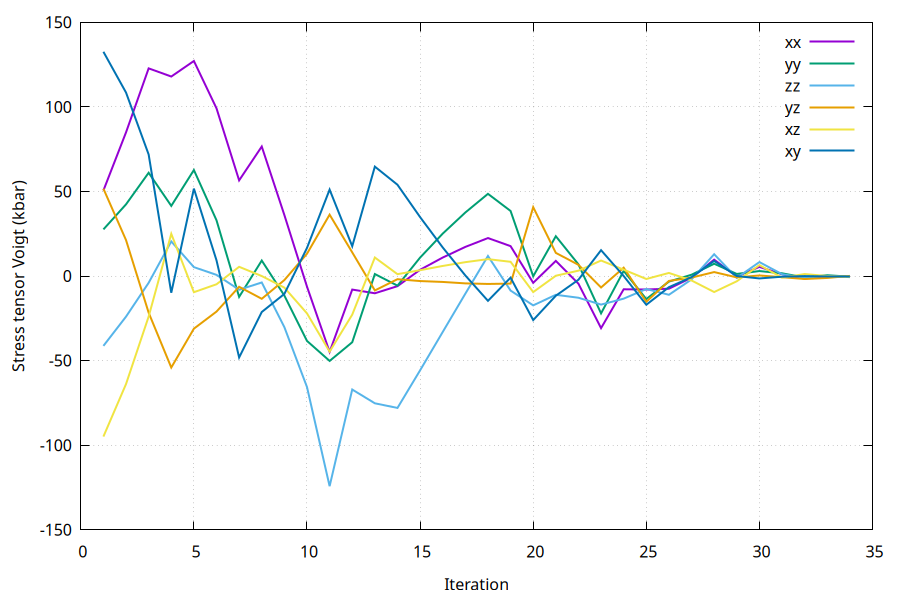

In [14]:
from IPython.display import Image, display
display(Image(filename="stress_iteration.png"))

In [5]:
!grep enth si8.out

Target enthalpy (eV/cell)     -916.1832
Target enthalpy (eV/cell)     -917.0587
Target enthalpy (eV/cell)     -917.7618
Target enthalpy (eV/cell)     -917.3919
Target enthalpy (eV/cell)     -917.8380
Target enthalpy (eV/cell)     -918.3276
Target enthalpy (eV/cell)     -918.3588
Target enthalpy (eV/cell)     -918.4119
Target enthalpy (eV/cell)     -918.7417
Target enthalpy (eV/cell)     -918.8595
Target enthalpy (eV/cell)     -918.7842
Target enthalpy (eV/cell)     -918.8600
Target enthalpy (eV/cell)     -919.0721
Target enthalpy (eV/cell)     -919.0755
Target enthalpy (eV/cell)     -919.3231
Target enthalpy (eV/cell)     -919.4762
Target enthalpy (eV/cell)     -919.5342
Target enthalpy (eV/cell)     -919.5006
Target enthalpy (eV/cell)     -919.5347
Target enthalpy (eV/cell)     -919.4793
Target enthalpy (eV/cell)     -919.5882
Target enthalpy (eV/cell)     -919.6368
Target enthalpy (eV/cell)     -919.5803
Target enthalpy (eV/cell)     -919.6385
Target enthalpy (eV/cell)     -919.6228


In [6]:
%%bash

# Extract Target enthalpy from SIESTA output
grep "enth" si8.out | awk '{print NR, $NF}' > energy.dat

# Plot using gnuplot
gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "energy_iteration.png"
set xlabel "Number of Iteration"
set ylabel "Energy (eV/cell)"
set grid
plot "energy.dat" using 1:2 with linespoints lw 2 title "Energy relaxation"
EOF


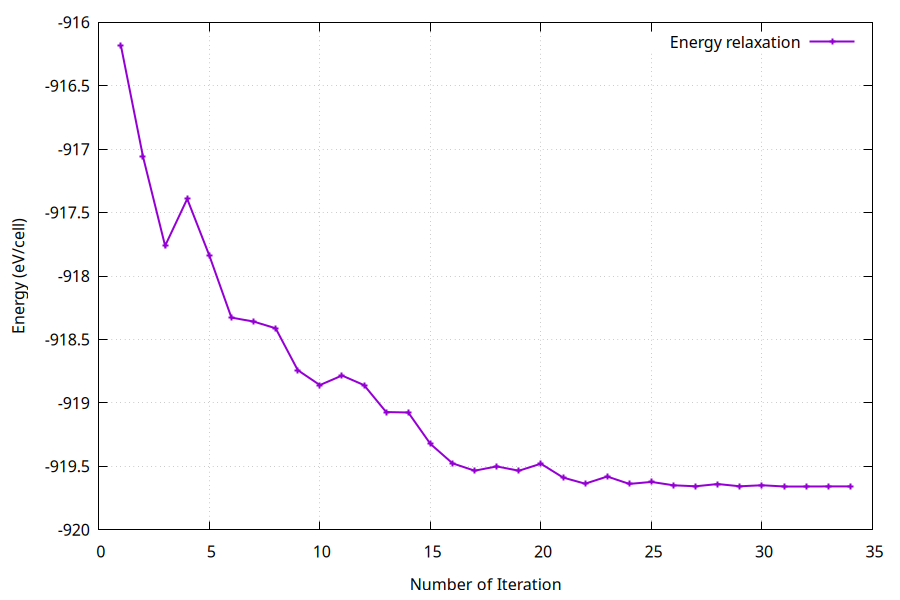

In [7]:
from IPython.display import Image, display
display(Image(filename="energy_iteration.png"))